# Deep Learning Architectures for Pneumonia Detection: Multi-Scale Analysis with Explainable AI

**DenseNet169 Fine-Tuned Models Notebook**

**Description:** This notebook fine-tunes the best performing DenseNet169 model on higher resolution images (64x64) to improve performance for subsequent XAI analysis.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [1]:
# Import utility libraries
import os
import sys
import time
from datetime import datetime
sys.path.append('..')  # Add parent directory to path to allow import of custom modules

# Import deep learning libraries
import tensorflow as tf

# Suppress TensorFlow warnings
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'    # 0=all, 1=info, 2=warning, 3=error
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'   # Disable oneDNN optimizations for reproducibility

# Disable verbose output from TensorFlow during training
tf_verbosity = 1  # 0 = silent, 1 = progress bar, 2 = one line per epoch

# Import custom utilities
from utils.data_utils import load_and_preprocess_multiscale_data
from utils.finetune_utils import (
    load_pretrained_model, extract_model_params,
    freeze_layers, generate_tuned_model_path
)
from utils.model.densenet_utils import adapt_densenet169_for_resolution, transfer_densenet169_weights
from utils.train_utils import get_callbacks
from utils.eval_utils import evaluate_model
from utils.plot_utils import plot_training_history, plot_roc_curve, plot_confusion_matrix
from utils.logger_utils import ModelLogger

2025-06-20 09:44:05.510584: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-20 09:44:05.528765: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750409045.550079   84408 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750409045.556198   84408 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-20 09:44:05.578768: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

# Core Variables

In [ ]:
# Global seed for reproducibility
RANDOM_SEED = 42

# Architecture and paths
ARCHITECTURE = 'densenet_169'             # Architecture name
DATA_PATH = '../data/'                    # Path to the dataset
OUTPUT_PATH = '../output/'                # Path to save output files
MODEL_PATH = OUTPUT_PATH + 'models/'      # Path to save models
LOG_PATH = OUTPUT_PATH + 'logs/'          # Path to save logs

# Fine-tuning parameters
ORIGINAL_SIZE = 28                        # Original training image size
TARGET_SIZE = 64                          # Target fine-tuning image size
FINE_TUNE_LR = 0.0001                     # Lower learning rate for fine-tuning (10x reduction)
FINE_TUNE_EPOCHS = 30                     # Number of fine-tuning epochs

# DenseNet169-specific freeze ratio
# Higher ratio = more frozen layers = preserves more pre-trained features
# Lower ratio = fewer frozen layers = allows more adaptation to new resolution
FREEZE_RATIO = 0.75    # DenseNet169: 75% - dense connections benefit from more frozen early layers
print(f"Using freeze ratio for {ARCHITECTURE}: {FREEZE_RATIO*100:.0f}%")

# Ensure directories exist
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(LOG_PATH, exist_ok=True)

Using freeze ratio for densenet_169: 75%


# Load Best Pre-trained Model

In [3]:
# Load the specified pre-trained model
MODEL_FILENAME = 'densenet_169_b96_lr0.001_dr0.5_pneumonia_model.keras'
best_model_path = os.path.join(MODEL_PATH, MODEL_FILENAME)

print(f"Loading pre-trained model: {best_model_path}")
pretrained_model = load_pretrained_model(best_model_path)
print(f"✓ Loaded model with {pretrained_model.count_params():,} parameters")

# Extract parameters from the model filename
original_params = extract_model_params(MODEL_FILENAME)
print("Parameters extracted from model filename:")
for key, value in original_params.items():
    print(f"  {key}: {value}")

Loading pre-trained model: ../output/models/densenet_169_b96_lr0.001_dr0.5_pneumonia_model.keras
Loading model from: ../output/models/densenet_169_b96_lr0.001_dr0.5_pneumonia_model.keras


I0000 00:00:1750409049.680194   84408 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2787 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Model loaded successfully: functional_2
✓ Loaded model with 13,505,096 parameters
Parameters extracted from model filename:
  batch_size: 96
  learning_rate: 0.001
  dropout_rate: 0.5
  augmented: False
  dropout_mode: fixed


# Data Loading & Preprocessing

In [4]:
# Load data with target resolution
print(f"Loading data with {TARGET_SIZE}x{TARGET_SIZE} resolution...")
train_dataset, (test_images, test_labels), (val_images, val_labels) = load_and_preprocess_multiscale_data(
    DATA_PATH,
    image_size=TARGET_SIZE,
    augment=original_params['augmented'],  # Use same augmentation as original model
    batch_size=original_params['batch_size'],
    seed=RANDOM_SEED
)
print(f"✓ Data loaded successfully")

Loading data with 64x64 resolution...

Dataset shapes - 64x64 resolution:
Train - images: (4708, 64, 64)  labels: (4708, 1)
Val   - images: (524, 64, 64)  labels: (524, 1)
Test  - images: (624, 64, 64)  labels: (624, 1)
✓ Data loaded successfully


# Model Adaptation & Fine-tuning Setup

In [5]:
# Adapt the DenseNet model for the new resolution
print(f"\nAdapting DenseNet169 from {ORIGINAL_SIZE}x{ORIGINAL_SIZE} to {TARGET_SIZE}x{TARGET_SIZE}...")

adapted_model = adapt_densenet169_for_resolution(
    pretrained_model, 
    TARGET_SIZE, 
    dropout_rate=original_params['dropout_rate']
)

print(f"✓ DenseNet169 successfully adapted from {ORIGINAL_SIZE}x{ORIGINAL_SIZE} to {TARGET_SIZE}x{TARGET_SIZE}")

# Transfer weights from the original model to the adapted model
print("Transferring compatible weights...")
adapted_model = transfer_densenet169_weights(pretrained_model, adapted_model)

# Freeze layers for fine-tuning
print(f"\nApplying freeze ratio of {FREEZE_RATIO*100:.0f}%...")
adapted_model = freeze_layers(adapted_model, freeze_ratio=FREEZE_RATIO)

print(f"\nModel setup complete for fine-tuning:")
print(f"  Architecture: DenseNet169")
print(f"  Original resolution: {ORIGINAL_SIZE}x{ORIGINAL_SIZE}")
print(f"  Target resolution: {TARGET_SIZE}x{TARGET_SIZE}")
print(f"  Freeze ratio: {FREEZE_RATIO*100:.0f}%")

adapted_model.summary()


Adapting DenseNet169 from 28x28 to 64x64...
Building new DenseNet169 for 64x64 resolution...
Using dropout rate: 0.5
✓ DenseNet169 successfully adapted from (None, 28, 28, 1) to (64, 64, 1)
Original parameters: 13,505,096
Adapted parameters: 13,505,096
✓ DenseNet169 successfully adapted from 28x28 to 64x64
Transferring compatible weights...

Transferring DenseNet169 weights...
✓ DenseNet169 successfully adapted from (None, 28, 28, 1) to (64, 64, 1)
Original parameters: 13,505,096
Adapted parameters: 13,505,096
✓ DenseNet169 successfully adapted from 28x28 to 64x64
Transferring compatible weights...

Transferring DenseNet169 weights...
✓ Dense layer fc: 2 units

DenseNet169 weight transfer complete: 1 layers transferred
Note: Pre-trained DenseNet169 base model weights are loaded from ImageNet automatically

Applying freeze ratio of 75%...
Frozen layers: 7
Trainable layers: 3

Model setup complete for fine-tuning:
  Architecture: DenseNet169
  Original resolution: 28x28
  Target resolut

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 3)      │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet169 (Functional)        │ (None, 7, 7, 1664)     │    12,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1664)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1664)           │         6,656 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       852,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,505,096 (51.52 MB)

 Trainable params: 2,050 (8.01 KB)

 Non-trainable params: 13,503,046 (51.51 MB)

# Model Compilation

In [6]:
# Compile for fine-tuning with lower learning rate
adapted_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',  # Updated to match one-hot encoded labels
    metrics=['accuracy', 'AUC']
)

print(f"\nModel compiled for fine-tuning:")
print(f"  Optimizer: Adam (lr={FINE_TUNE_LR})")
print(f"  Loss: Categorical crossentropy")
print(f"  Metrics: Accuracy, AUC")


Model compiled for fine-tuning:
  Optimizer: Adam (lr=0.0001)
  Loss: Categorical crossentropy
  Metrics: Accuracy, AUC


# Fine-tuning Setup

In [7]:
# Generate path for fine-tuned model
tuned_model_path = generate_tuned_model_path(
    original_params, 
    TARGET_SIZE, 
    MODEL_PATH, 
    ARCHITECTURE
)
print(f"Fine-tuned model will be saved to: {tuned_model_path}")

# Setup logger for fine-tuning
logger = ModelLogger()
tuned_model_info = {
    "model_name": f"{ARCHITECTURE}_tuned",
    "original_model": best_model_path,
    "original_size": ORIGINAL_SIZE,
    "target_size": TARGET_SIZE,
    "fine_tune_lr": FINE_TUNE_LR,
    "freeze_ratio": FREEZE_RATIO,
    "epochs": FINE_TUNE_EPOCHS,
    "batch_size": original_params['batch_size'],
    "augmented": original_params['augmented'],
    "dropout_rate": original_params['dropout_rate'],
    "random_seed": RANDOM_SEED
}
logger.initialize_run(tuned_model_info)

Fine-tuned model will be saved to: ../output/models/densenet_169_tuned_b96_lr0.001_dr0.5_64px_pneumonia_model.keras


# Fine-tuning Training


Starting fine-tuning for 30 epochs...
Epoch 1/30


I0000 00:00:1750409067.584667   84524 service.cc:148] XLA service 0x70ff080037b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750409067.584684   84524 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti with Max-Q Design, Compute Capability 7.5
2025-06-20 09:44:28.022566: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-06-20 09:44:28.022566: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1750409070.763516   84524 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1750409070.763516   84524 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-06-20 09:44:57.838391: W external/local_xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.4 which is older t

50/50 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - AUC: 0.7185 - accuracy: 0.6608 - loss: 0.7458 - val_AUC: 0.9361 - val_accuracy: 0.8435 - val_loss: 0.5614 - learning_rate: 1.0000e-04
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - AUC: 0.7185 - accuracy: 0.6608 - loss: 0.7458 - val_AUC: 0.9361 - val_accuracy: 0.8435 - val_loss: 0.5614 - learning_rate: 1.0000e-04
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 449ms/step - AUC: 0.8125 - accuracy: 0.7506 - loss: 0.6158 - val_AUC: 0.9238 - val_accuracy: 0.8225 - val_loss: 0.4837 - learning_rate: 1.0000e-04
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 449ms/step - AUC: 0.8125 - accuracy: 0.7506 - loss: 0.6158 - val_AUC: 0.9238 - val_accuracy: 0.8225 - val_loss: 0.4837 - learning_rate: 1.0000e-04
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 447ms/step - AUC: 0.8585 - accuracy: 0.7838 - loss: 0.5213 - val_AUC: 0.9228 - val_accuracy: 0.8149 - val_loss: 0.4315 - learning_rate: 1.0000e-04
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 447ms/step - AUC: 0.8585 - a

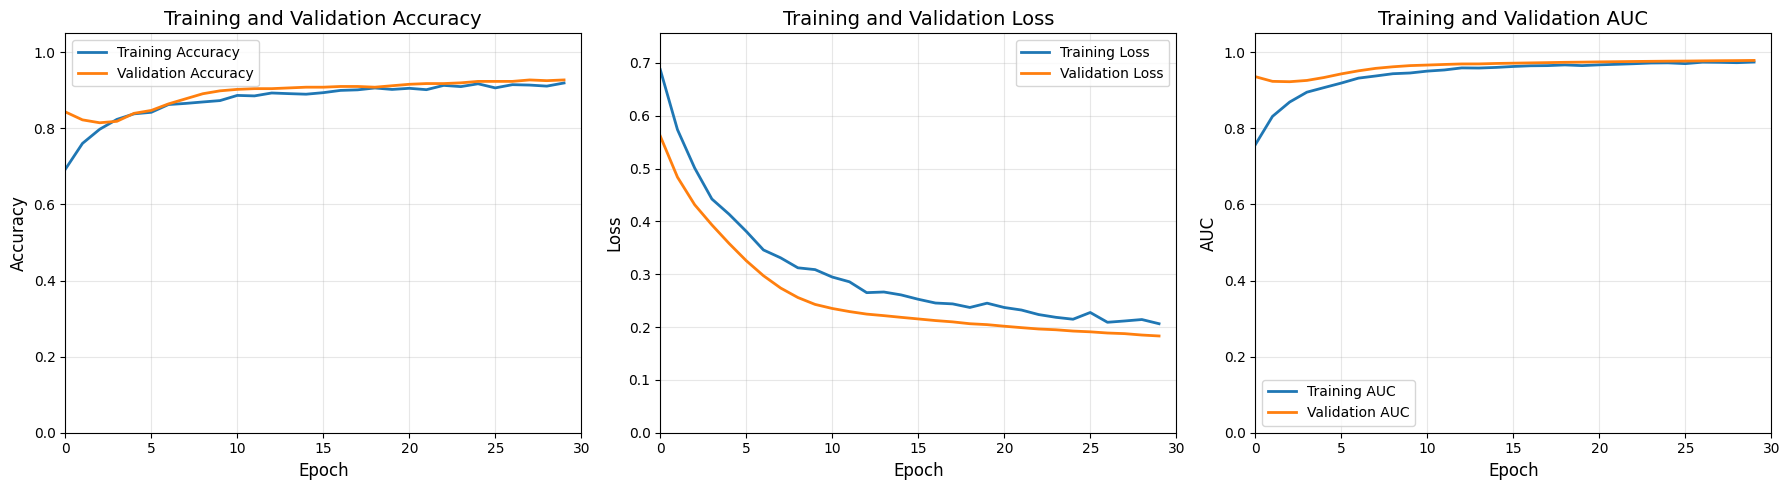

In [8]:
# Get callbacks for fine-tuning
callbacks = get_callbacks(
    tuned_model_path,
    monitor='val_AUC',
    mode='max',
    patience=10,
    factor=0.5  # Use lower factor for fine-tuning (more aggressive LR reduction)
)

# Start fine-tuning
print(f"\nStarting fine-tuning for {FINE_TUNE_EPOCHS} epochs...")
start_time = time.time()

history = adapted_model.fit(
    train_dataset,
    validation_data=(val_images, val_labels),
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks,
    verbose=tf_verbosity
)

exec_time = round(time.time() - start_time, 2)
print(f"\nFine-tuning completed in {exec_time} seconds")

# Save training info to logger
logger.add_training_info(history, exec_time)

# Set final model for evaluation
final_model = adapted_model

print("✓ Fine-tuning completed successfully!")

# Plot training history
plot_training_history(history)

# Evaluation


Evaluating fine-tuned model on test set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - AUC: 0.9387 - accuracy: 0.8661 - loss: 0.3355 
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - AUC: 0.9387 - accuracy: 0.8661 - loss: 0.3355
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 839ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 839ms/step


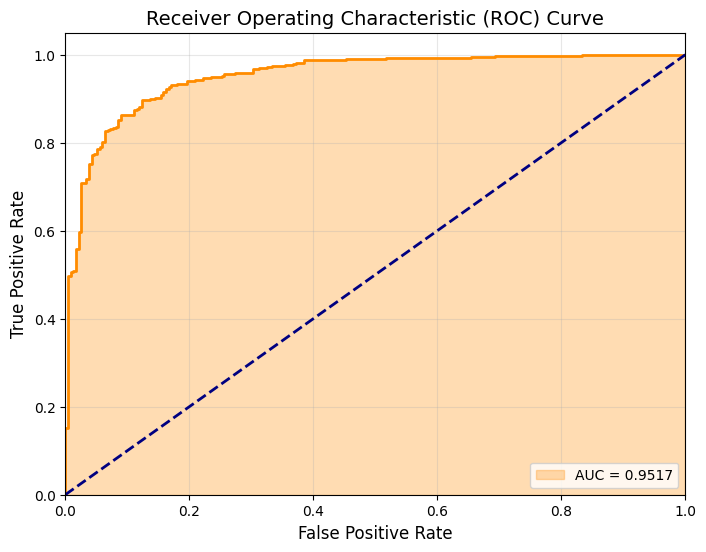

ROC AUC Score: 0.951720


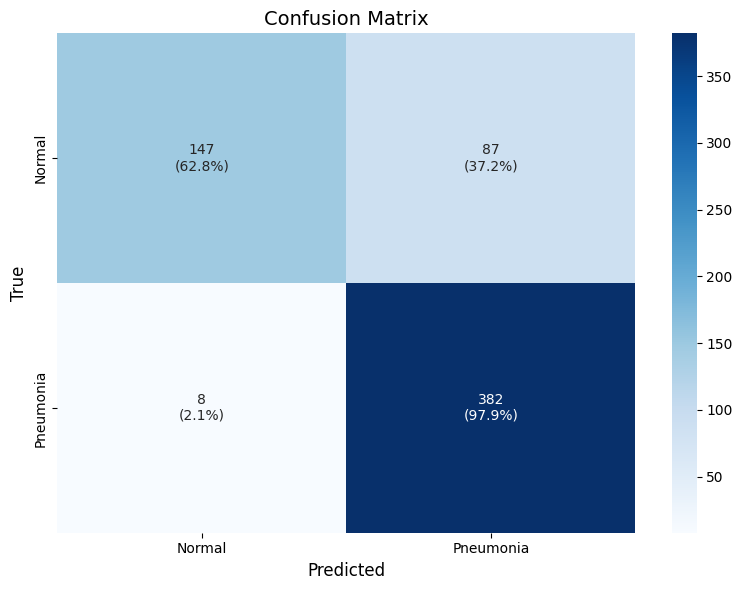


Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.63      0.76       234
   Pneumonia       0.81      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.88      0.80      0.82       624
weighted avg       0.86      0.85      0.84       624



In [9]:
# Evaluate the fine-tuned model (using model from memory)
print("\nEvaluating fine-tuned model on test set...")

# Evaluate using the final model
results = evaluate_model(final_model, test_images, test_labels, verbose=tf_verbosity)

# Add evaluation results to logger
logger.add_evaluation_results(results)

# Plot results
plot_roc_curve(results['roc']['fpr'], results['roc']['tpr'], results['roc']['auc'])
plot_confusion_matrix(results['confusion_matrix'])
print("\nClassification Report:")
print(results['classification_report'])

# Save Results

In [10]:
# Save fine-tuning log
tuned_log_path = os.path.join(LOG_PATH, f"{ARCHITECTURE}_tuned_{TARGET_SIZE}px_info.json")
logger.save(tuned_log_path)

print(f"\n✅ Fine-tuning completed successfully!")
print(f"📁 Model saved: {tuned_model_path}")
print(f"📊 Logs saved: {tuned_log_path}")
print(f"🎯 Final accuracy: {results['test_accuracy']:.4f}")
print(f"📈 Final AUC: {results['test_auc']:.4f}")
print(f"🔍 The DenseNet169 model is now ready for XAI analysis at {TARGET_SIZE}x{TARGET_SIZE} resolution.")

Run information saved to ../output/logs/densenet_169_tuned_64px_info.json

✅ Fine-tuning completed successfully!
📁 Model saved: ../output/models/densenet_169_tuned_b96_lr0.001_dr0.5_64px_pneumonia_model.keras
📊 Logs saved: ../output/logs/densenet_169_tuned_64px_info.json
🎯 Final accuracy: 0.8478
📈 Final AUC: 0.9312
🔍 The DenseNet169 model is now ready for XAI analysis at 64x64 resolution.
